<a href="https://colab.research.google.com/github/DineshaTennakoon/DineshaTennakoon/blob/main/Model_Codes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Colab/Drive setup
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:

DATA_DIR = '/content/drive/MyDrive/Dataset'
TRAIN_PATH = f'{DATA_DIR}/train.csv'
TEST_PATH  = f'{DATA_DIR}/test.csv'
SAMPLE_SUB_PATH = f'{DATA_DIR}/sample_submission.csv'
SUBMISSION_OUT = '/content/submission.csv'
MODEL_DIR = '/content/models'

# Libraries
!pip -q install shap==0.46.0 xgboost==2.1.1 optuna==3.6.1

import os, gc, json, warnings, math, random, pathlib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, f1_score,
    precision_recall_curve, roc_curve, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from xgboost import XGBClassifier
import shap
import optuna

# Reproducibility
SEED = 42
np.random.seed(SEED); random.seed(SEED)

os.makedirs(MODEL_DIR, exist_ok=True)
pd.set_option('display.max_columns', 200)

# **Load Data & Quick Sanity Checks**

In [3]:
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print('Train shape:', train.shape)
print('Test  shape:', test.shape)

# Identify target and potential ID column
TARGET = 'rainfall'  # as per your brief
assert TARGET in train.columns, f"Expected target column '{TARGET}' not found!"

# Use sample submission to decide row order / id key
sub_cols = list(sample_sub.columns)
print('Sample submission columns:', sub_cols)

# We'll use row order unless the sample has an explicit id key
submission_key = None
if len(sub_cols) == 2:
    # e.g., ['id','rainfall']
    possible_key = sub_cols[0]
    if possible_key in test.columns:
        submission_key = possible_key
        print(f"Detected submission key: {submission_key}")
else:
    print("No explicit submission id detected, falling back to row order.")

# Separate features/target
y = train[TARGET].astype(int)
X = train.drop(columns=[TARGET])

# Remove exact-duplicate columns if any
X = X.loc[:, ~X.columns.duplicated()]
test = test.loc[:, X.columns] if set(X.columns).issubset(test.columns) else test

print('X columns:', len(X.columns))
X.head()

Train shape: (2190, 13)
Test  shape: (730, 12)
Sample submission columns: ['id', 'rainfall']
Detected submission key: id
X columns: 12


,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8


# **Basic EDA**

,count
float64,10
int64,2



Missing values (train):


,0
id,0
day,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
sunshine,0



Target balance:
rainfall
1    0.753425
0    0.246575
Name: proportion, dtype: float64


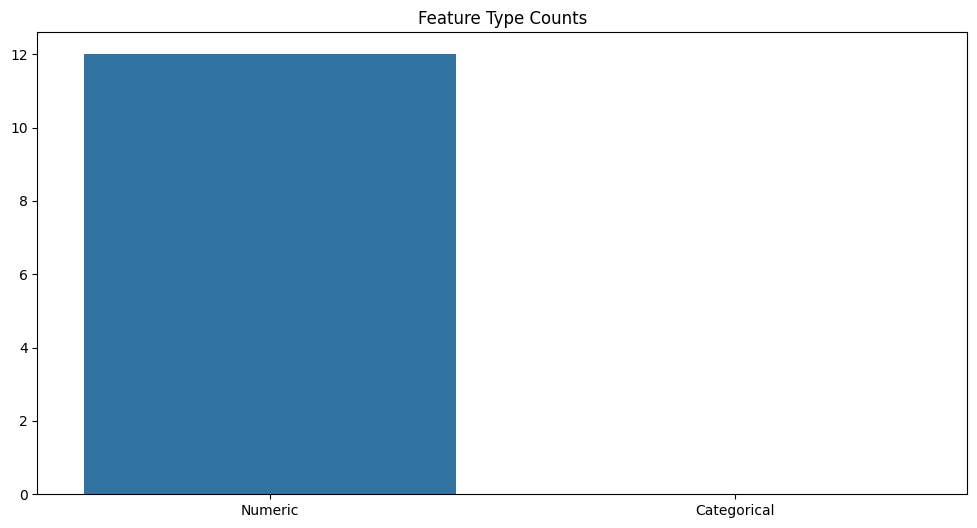

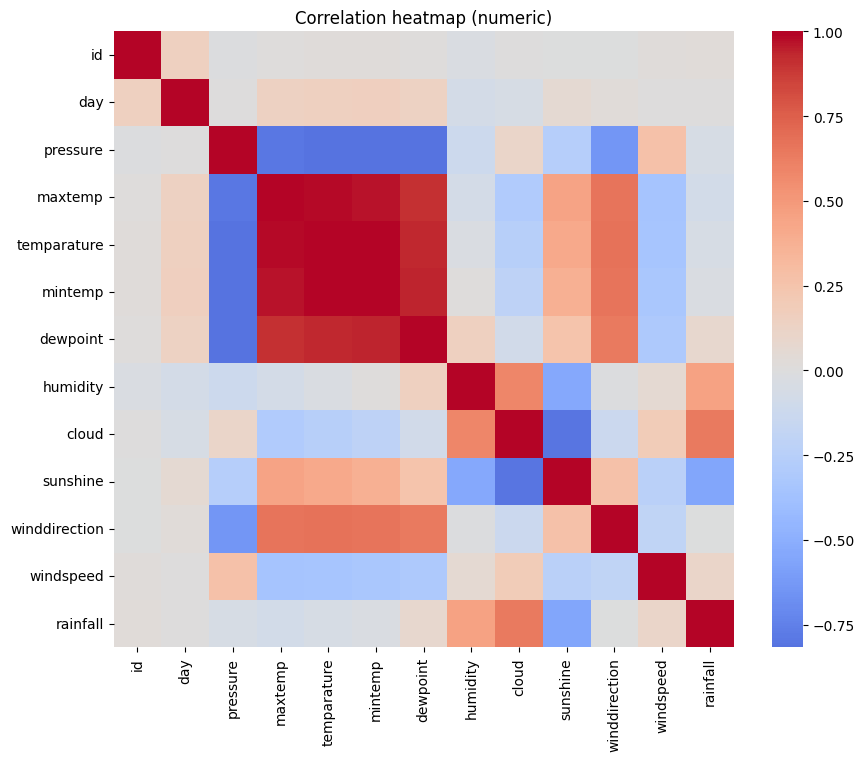

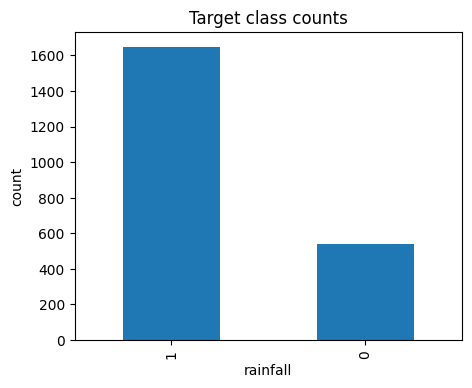

In [4]:
# Data types & missingness
display(X.dtypes.value_counts())
print("\nMissing values (train):")
display(train.isna().sum().sort_values(ascending=False).head(20))

print("\nTarget balance:")
print(y.value_counts(normalize=True).rename('proportion'))

# Histograms for numeric features
num_cols = X.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=['Numeric','Categorical'], y=[len(num_cols), len(cat_cols)], ax=ax)
ax.set_title('Feature Type Counts')
plt.show()

# Correlation heatmap for top numeric
if len(num_cols) > 1:
    corr = train[num_cols + [TARGET]].corr(numeric_only=True)
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap='coolwarm', center=0)
    plt.title('Correlation heatmap (numeric)')
    plt.show()

# Class balance chart
plt.figure(figsize=(5,4))
y.value_counts().plot(kind='bar')
plt.title('Target class counts')
plt.xlabel('rainfall'); plt.ylabel('count')
plt.show()

# **Preprocessing Pipelines**

In [5]:
numeric_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler(with_mean=False))  # works for sparse
])

categorical_transform = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))  # updated
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transform, num_cols),
        ('cat', categorical_transform, cat_cols)
    ],
    remainder='drop',
    sparse_threshold=0.3
)

# Train/validation split
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# **Helper Functions (metrics, plots, thresholding)**

In [6]:
def evaluate_probs(y_true, y_prob, title='Validation'):
    y_prob = np.asarray(y_prob)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    prec, rec, thr = precision_recall_curve(y_true, y_prob)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    print(f"[{title}] ROC AUC: {roc_auc:.4f} | PR AUC: {pr_auc:.4f}")

    # Choose thresholds:
    # 1) default 0.5
    y_pred_05 = (y_prob >= 0.5).astype(int)
    acc_05 = accuracy_score(y_true, y_pred_05)
    f1_05  = f1_score(y_true, y_pred_05)

    # 2) maximize F1 on validation
    best_f1, best_thr = 0.0, 0.5
    for t in np.linspace(0.01, 0.99, 99):
        f1 = f1_score(y_true, (y_prob >= t).astype(int))
        if f1 > best_f1:
            best_f1, best_thr = f1, t

    print(f"[{title}] Acc@0.5: {acc_05:.4f} | F1@0.5: {f1_05:.4f}")
    print(f"[{title}] Best F1: {best_f1:.4f} @ thr={best_thr:.3f}")

    # Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(12,5))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred_05, ax=axes[0], colorbar=False
    )
    axes[0].set_title('Confusion Matrix @ 0.5')

    y_pred_best = (y_prob >= best_thr).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred_best, ax=axes[1], colorbar=False
    )
    axes[1].set_title(f'Confusion Matrix @ best thr={best_thr:.2f}')
    plt.show()

    # ROC curve
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC AUC={roc_auc:.4f}')
    plt.plot([0,1],[0,1],'--',lw=1)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'ROC - {title}')
    plt.legend()
    plt.show()

    # PR curve
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label=f'PR AUC={pr_auc:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title(f'PR - {title}')
    plt.legend()
    plt.show()

    return {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'best_thr': best_thr,
            'acc@0.5': acc_05, 'f1@0.5': f1_05, 'best_f1': best_f1}

# **Baseline: Logistic Regression (solid reference)**

[Logistic Regression (val)] ROC AUC: 0.8783 | PR AUC: 0.9469
[Logistic Regression (val)] Acc@0.5: 0.8333 | F1@0.5: 0.8872
[Logistic Regression (val)] Best F1: 0.9145 @ thr=0.290


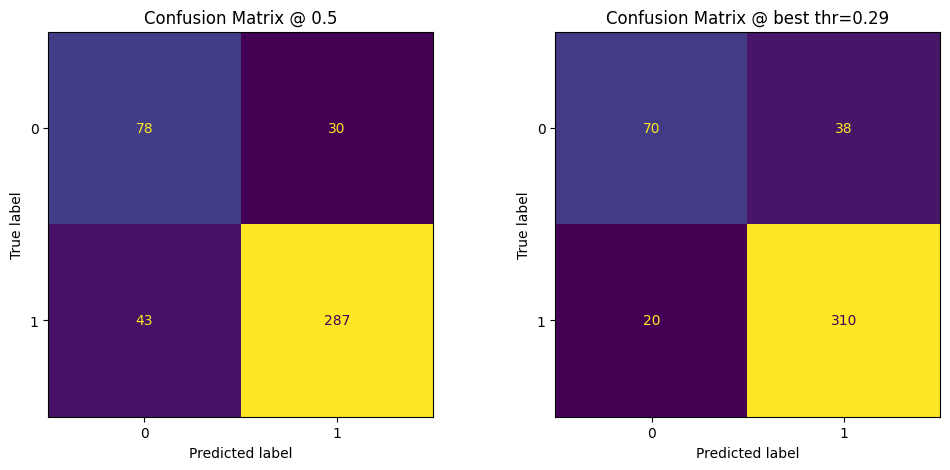

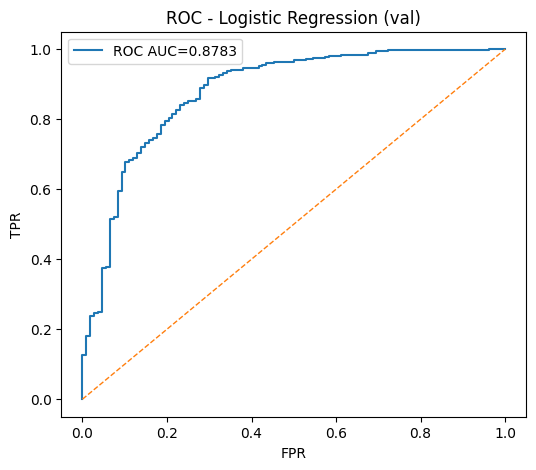

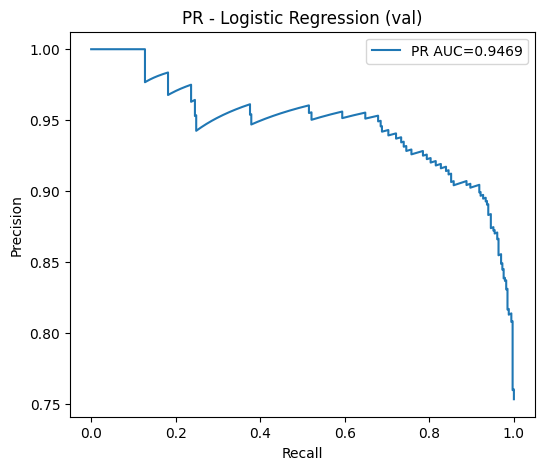

In [7]:
logreg = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=5000, class_weight='balanced', n_jobs=None))
])

logreg.fit(X_train, y_train)
val_probs_lr = logreg.predict_proba(X_valid)[:,1]
metrics_lr = evaluate_probs(y_valid, val_probs_lr, title='Logistic Regression (val)')

# **SVM (with probability) + Calibration**

[SVM (calibrated, val)] ROC AUC: 0.8669 | PR AUC: 0.9441
[SVM (calibrated, val)] Acc@0.5: 0.8653 | F1@0.5: 0.9134
[SVM (calibrated, val)] Best F1: 0.9134 @ thr=0.500


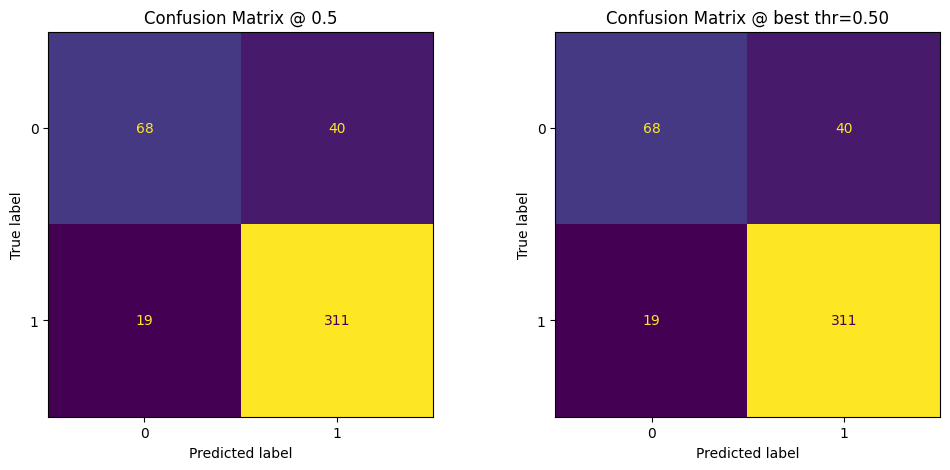

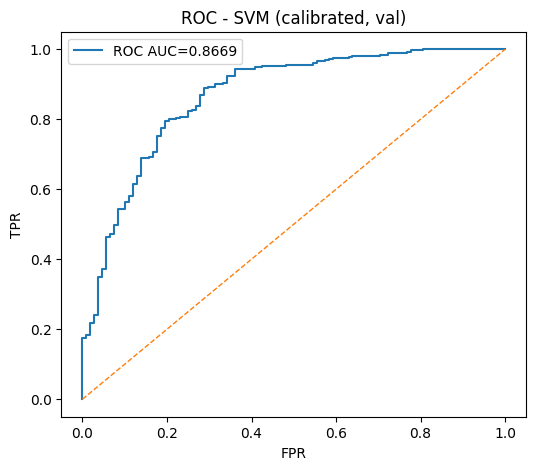

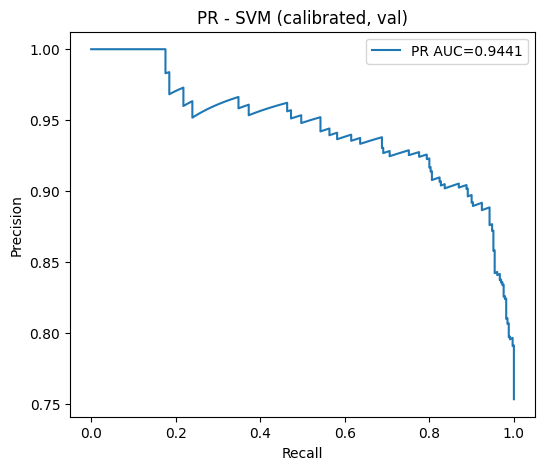

In [8]:
svm_pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, class_weight='balanced', random_state=SEED))
])

svm_cal = CalibratedClassifierCV(svm_pipe, method='sigmoid', cv=3)
svm_cal.fit(X_train, y_train)
val_probs_svm = svm_cal.predict_proba(X_valid)[:,1]
metrics_svm = evaluate_probs(y_valid, val_probs_svm, title='SVM (calibrated, val)')

# **Decision Tree**

[Decision Tree (val)] ROC AUC: 0.7943 | PR AUC: 0.8878
[Decision Tree (val)] Acc@0.5: 0.7922 | F1@0.5: 0.8553
[Decision Tree (val)] Best F1: 0.8978 @ thr=0.080


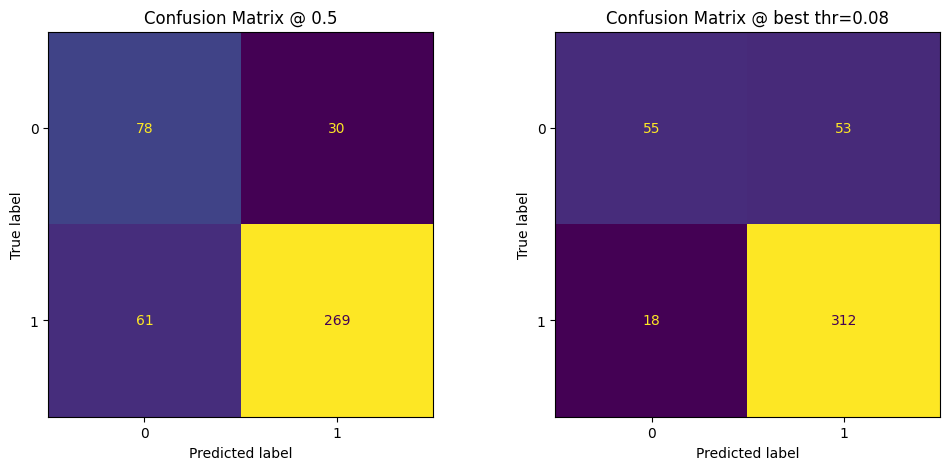

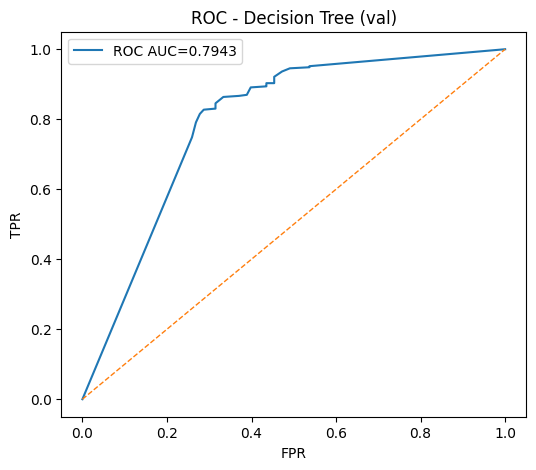

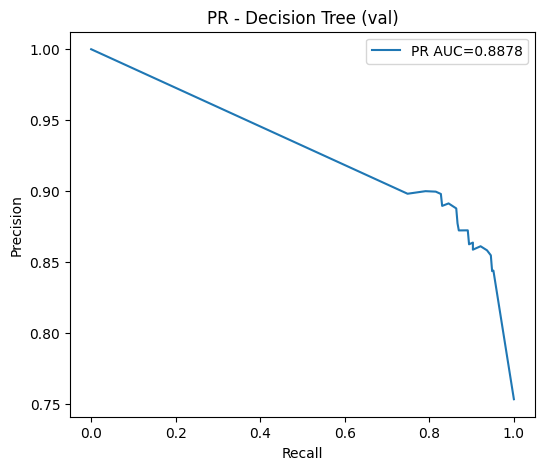

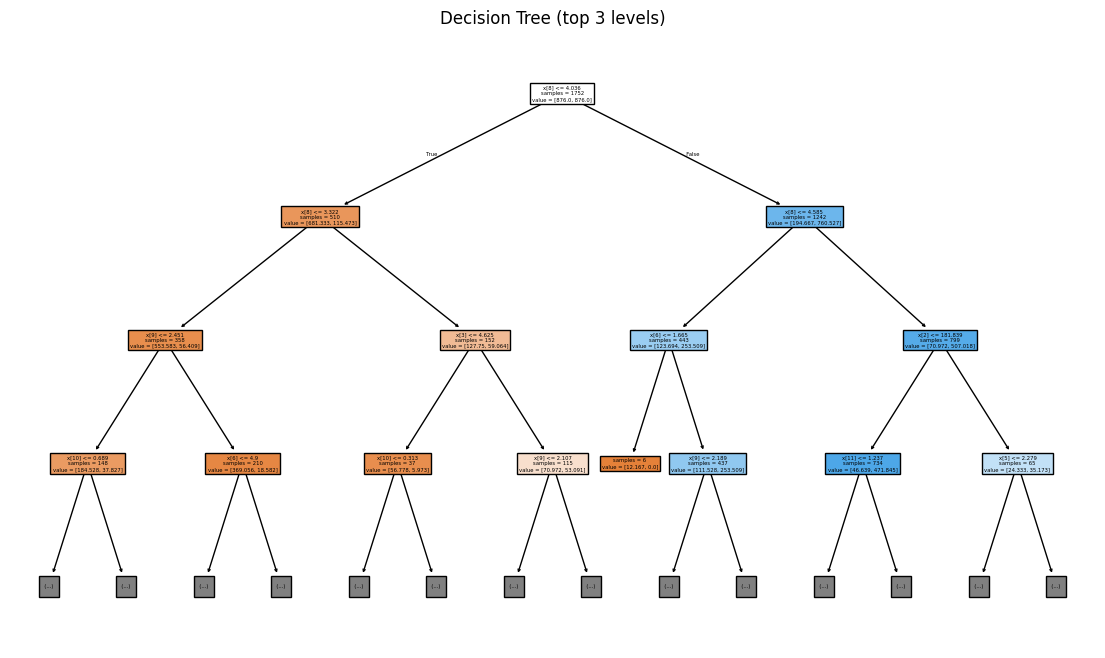

In [9]:
dt_pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', DecisionTreeClassifier(
        max_depth=None, min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=SEED
    ))
])

dt_pipe.fit(X_train, y_train)
val_probs_dt = dt_pipe.predict_proba(X_valid)[:,1]
metrics_dt = evaluate_probs(y_valid, val_probs_dt, title='Decision Tree (val)')

# Optional: visualize small tree (only if trained on dense subset; big trees get messy)
try:
    # Extract the fitted tree estimator from the pipeline
    fitted_tree = dt_pipe.named_steps['clf']
    plt.figure(figsize=(14,8))
    plot_tree(fitted_tree, max_depth=3, filled=True, impurity=False)
    plt.title('Decision Tree (top 3 levels)')
    plt.show()
except Exception as e:
    print("Tree plot skipped:", e)

# **Random Forest (Ensemble)**

[Random Forest (val)] ROC AUC: 0.8751 | PR AUC: 0.9465
[Random Forest (val)] Acc@0.5: 0.8630 | F1@0.5: 0.9099
[Random Forest (val)] Best F1: 0.9165 @ thr=0.380


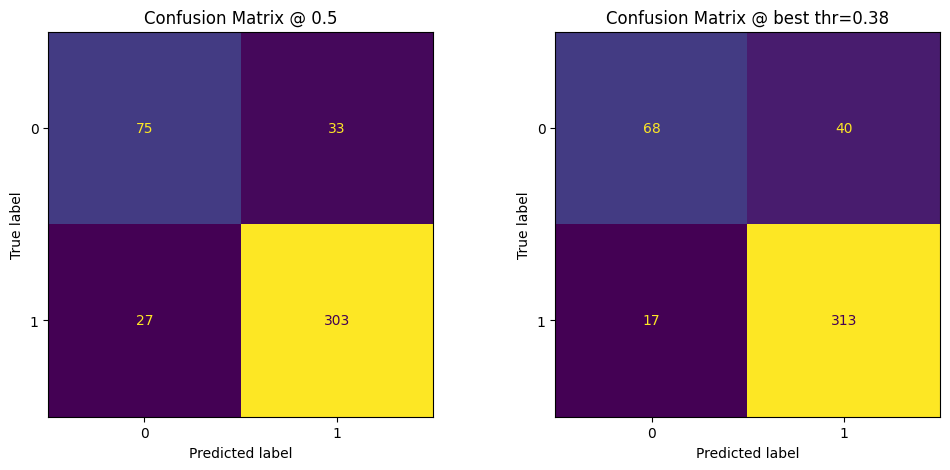

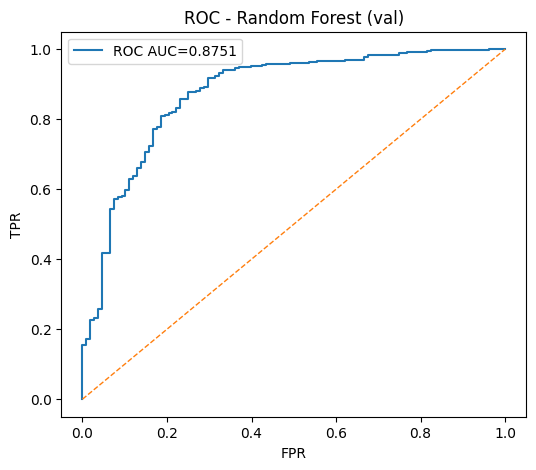

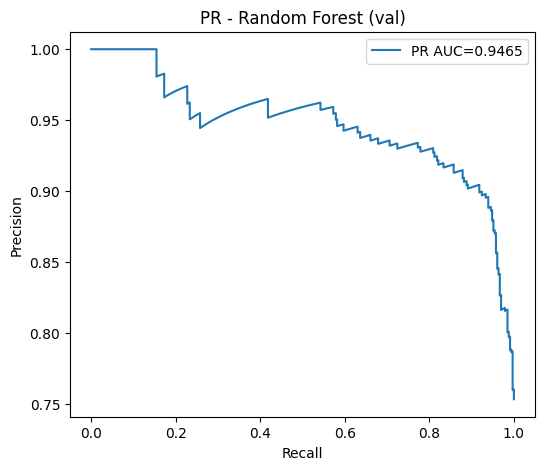

In [10]:
rf_pipe = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=400, max_depth=None, max_features='sqrt',
        min_samples_split=10, min_samples_leaf=3, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)
val_probs_rf = rf_pipe.predict_proba(X_valid)[:,1]
metrics_rf = evaluate_probs(y_valid, val_probs_rf, title='Random Forest (val)')

# **Simple Neural Network (Keras)**

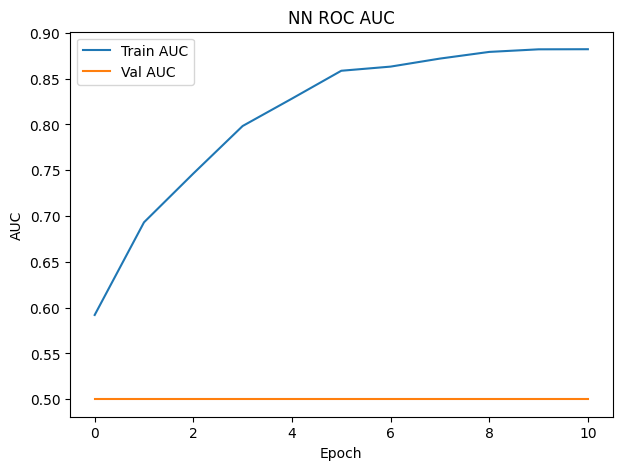

[Neural Network (val)] ROC AUC: 0.7357 | PR AUC: 0.8737
[Neural Network (val)] Acc@0.5: 0.7534 | F1@0.5: 0.8594
[Neural Network (val)] Best F1: 0.8594 @ thr=0.010


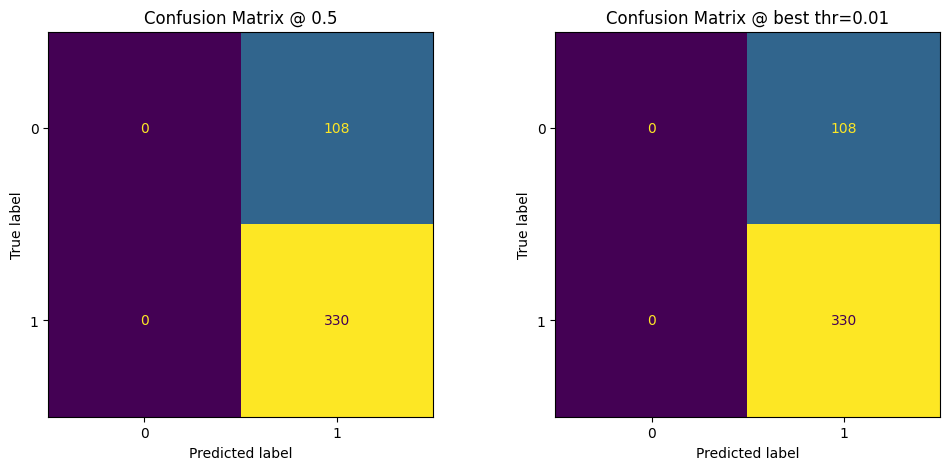

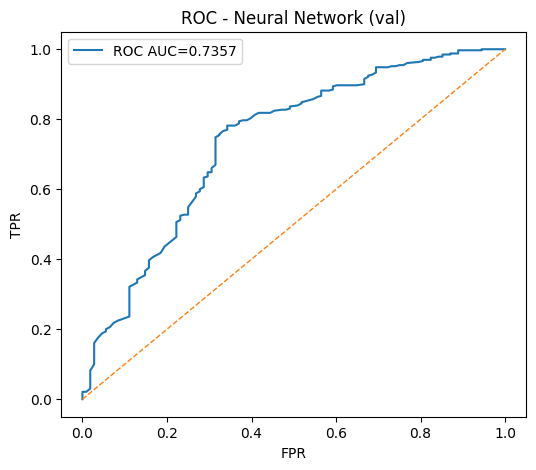

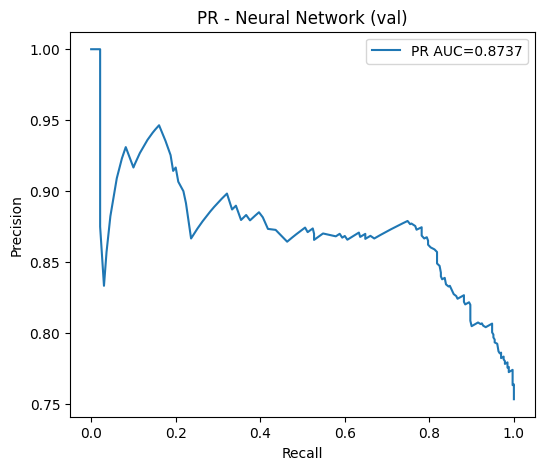

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build a Keras model that accepts the *transformed* features
# We'll use the preprocess to transform into a dense matrix first
from scipy import sparse

prep_only = preprocess.fit(X_train)  # fit separately
Xtr_sp = prep_only.transform(X_train)
Xva_sp = prep_only.transform(X_valid)

# Convert to dense only if small enough; otherwise use tf.sparse
def to_dense_safe(spm):
    if sparse.issparse(spm):
        if spm.shape[1] > 1_000_000:
            raise MemoryError("Too many features after one-hot; consider hashing trick.")
        return spm.toarray()
    return spm

Xtr = to_dense_safe(Xtr_sp)
Xva = to_dense_safe(Xva_sp)

tf.random.set_seed(SEED)

def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc'),
                           keras.metrics.AUC(curve='PR', name='pr_auc')])
    return model

nn = build_nn(Xtr.shape[1])
cb = [
    keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True, monitor='val_auc'),
    keras.callbacks.ReduceLROnPlateau(patience=5, factor=0.5, monitor='val_auc')
]
hist = nn.fit(
    Xtr, y_train.values,
    validation_data=(Xva, y_valid.values),
    epochs=100,
    batch_size=1024,
    callbacks=cb,
    verbose=0
)

# Plot training curves
plt.figure(figsize=(7,5))
plt.plot(hist.history['auc'], label='Train AUC')
plt.plot(hist.history['val_auc'], label='Val AUC')
plt.title('NN ROC AUC')
plt.xlabel('Epoch'); plt.ylabel('AUC'); plt.legend(); plt.show()

val_probs_nn = nn.predict(Xva, verbose=0).ravel()
metrics_nn = evaluate_probs(y_valid, val_probs_nn, title='Neural Network (val)')

In [16]:
import os
import joblib
import pandas as pd

# --- Paths (reuse your existing variables if already defined) ---
# MODEL_DIR should already exist from earlier cells
BEST_MODEL_PATHS = [
    f'{MODEL_DIR}/best_rf_model.pkl',  # preferred (RF you saved)
    f'{MODEL_DIR}/best_model.pkl'      # fallback, if you used a different filename
]

# Load the trained pipeline (includes preprocessing)
model_path = next((p for p in BEST_MODEL_PATHS if os.path.exists(p)), None)
assert model_path is not None, f"Trained model not found. Looked for: {BEST_MODEL_PATHS}"
model = joblib.load(model_path)
print(f"Loaded model from: {model_path}")

# --- Get a single-row example with correct columns ---
try:
    example = X.head(1).copy()
except NameError:
    # Fallback: read train and drop target if present
    train_df = pd.read_csv(TRAIN_PATH)
    example = train_df.head(1).copy()
    if 'rainfall' in example.columns:
        example = example.drop(columns=['rainfall'])

# Predict probability using the pipeline (handles all preprocessing internally)
pred_prob = model.predict_proba(example)[:, 1][0]
print(f"Predicted probability of rainfall: {pred_prob:.3f}")

# -------- Optional: helper to predict from a dict (e.g., form submission) --------
def predict_from_dict(feature_dict: dict) -> float:
    """
    Pass a dictionary of features (keys must match training feature names).
    Returns the predicted rainfall probability.
    """
    df = pd.DataFrame([feature_dict])
    return float(model.predict_proba(df)[:, 1][0])


Loaded model from: /content/models/best_rf_model.pkl
Predicted probability of rainfall: 0.926


In [12]:
# =======================
# Use Random Forest as final model
# =======================

best_model = rf_pipe  # use Random Forest pipeline

# Refit on full training data
best_model.fit(X, y)

# Predict probabilities for test set
X_test = test.loc[:, X.columns]  # ensure same column order
test_probs = best_model.predict_proba(X_test)[:, 1]

# Prepare submission
out = sample_sub.copy()

# Identify target column in sample submission (usually 'rainfall')
target_col_in_sub = [c for c in sample_sub.columns if c.lower() != 'id'][0]
out[target_col_in_sub] = test_probs

# Save CSV
out.to_csv(SUBMISSION_OUT, index=False)
print(f"✅ Submission written to: {SUBMISSION_OUT}")

# Optionally, save model for later use
import joblib
joblib.dump(best_model, f'{MODEL_DIR}/best_rf_model.pkl')
joblib.dump(preprocess, f'{MODEL_DIR}/preprocess.pkl')
print(f"✅ Saved model & preprocess to {MODEL_DIR}")


✅ Submission written to: /content/submission.csv
✅ Saved model & preprocess to /content/models
